### WEATHER TREND FORECASTING

### PROJECT OVERVIEW
Weather forecasting and climate trend analysis play a vital role in agriculture, transportation, disaster preparedness, public health and environmental planning. By leveraging historical weather observations, we can identify patterns, understand seasonal variations and develop predictive models to forecast future weather conditions.

In this project, the Global Weather Repository dataset is analyzed to explore historical weather trends across cities worldwide. The project involves data cleaning, exploratory data analysis (EDA), feature engineering and time series forecasting to predict future weather patterns. Both statistical analysis and machine learning techniques are applied to uncover meaningful insights and evaluate forecasting performance.

### OBJECTIVES
   The main objectives of this project are to:

* Explore and understand the structure of the Global Weather Repository dataset.
* Clean and preprocess the data to improve its quality and reliability.
* Perform exploratory data analysis to identify trends, distributions and relationships among weather variables.
* Engineer meaningful features to enhance predictive performance.
* Analyze temporal weather patterns and seasonal variations.
* Build and evaluate forecasting models to predict future weather trends.
* Present findings through informative visualizations and actionable insights.

### DATASET DESCRIPTION

The dataset used in this project is the Global Weather Repository obtained from Kaggle. It contains 21,322 daily weather observations collected from cities around the world and includes over 40 weather-related variables.

The dataset provides information such as:

* Temperature
* Humidity
* Wind speed and direction
* Atmospheric pressure
* Precipitation
* Visibility
* UV Index
* Air Quality Index (AQI)
* Cloud cover
* Sunrise and sunset times
* Moon phase
* Geographic information including city and country




### PROJECT WORKFLOW

The project follows the standard data science workflow:

1. Import libraries and load the dataset.
2. Perform data inspection and quality assessment.
3. Clean and preprocess the data.
4. Conduct exploratory data analysis (EDA).
5. Engineer relevant features.
6. Perform time series analysis.
7. Develop and evaluate forecasting models.
8. Visualize results and communicate insights.
9. Draw conclusions and provide recommendations.

In [155]:
#Importing libraries

# Data manipulation
import pandas as pd

# Data visualization
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns

# Machine learning
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score,mean_absolute_error

# Time series analysis


# Ignoring warnings
import warnings
warnings.filterwarnings('ignore')


In [156]:
# Loading the dataset
df = pd.read_csv('GlobalWeatherRepository.csv')

# Displaying the first 10 rows of the dataset
df.head(100)

,country,location_name,latitude,longitude,timezone,last_updated_epoch,last_updated,temperature_celsius,temperature_fahrenheit,condition_text,...,air_quality_PM2.5,air_quality_PM10,air_quality_us-epa-index,air_quality_gb-defra-index,sunrise,sunset,moonrise,moonset,moon_phase,moon_illumination
0,Afghanistan,Kabul,34.52,69.18,Asia/Kabul,1715849100,2024-05-16 13:15,26.6,79.8,Partly Cloudy,...,8.4,26.6,1,1,04:50 AM,06:50 PM,12:12 PM,01:11 AM,Waxing Gibbous,55
1,Albania,Tirana,41.33,19.82,Europe/Tirane,1715849100,2024-05-16 10:45,19.0,66.2,Partly cloudy,...,1.1,2.0,1,1,05:21 AM,07:54 PM,12:58 PM,02:14 AM,Waxing Gibbous,55
2,Algeria,Algiers,36.76,3.05,Africa/Algiers,1715849100,2024-05-16 09:45,23.0,73.4,Sunny,...,10.4,18.4,1,1,05:40 AM,07:50 PM,01:15 PM,02:14 AM,Waxing Gibbous,55
3,Andorra,Andorra La Vella,42.50,1.52,Europe/Andorra,1715849100,2024-05-16 10:45,6.3,43.3,Light drizzle,...,0.7,0.9,1,1,06:31 AM,09:11 PM,02:12 PM,03:31 AM,Waxing Gibbous,55
4,Angola,Luanda,-8.84,13.23,Africa/Luanda,1715849100,2024-05-16 09:45,26.0,78.8,Partly cloudy,...,183.4,262.3,5,10,06:12 AM,05:55 PM,01:17 PM,12:38 AM,Waxing Gibbous,55
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,Lesotho,Maseru,-29.32,27.48,Africa/Johannesburg,1715849100,2024-05-16 10:45,18.0,64.4,Sunny,...,29.8,46.6,2,3,06:47 AM,05:25 PM,01:39 PM,12:14 AM,Waxing Gibbous,55
96,Liberia,Monrovia,6.31,-10.80,Africa/Monrovia,1715849100,2024-05-16 08:45,26.0,78.8,Partly cloudy,...,1.7,4.1,1,1,06:27 AM,06:52 PM,01:43 PM,01:33 AM,Waxing Gibbous,55
97,Thailand,Nan,18.78,100.78,Asia/Bangkok,1715849100,2024-05-16 15:45,33.0,91.4,Patchy light rain with thunder,...,2.8,3.0,1,1,05:43 AM,06:44 PM,12:50 PM,01:10 AM,Waxing Gibbous,55
98,Liechtenstein,Vaduz,47.13,9.52,Europe/Vaduz,1715849100,2024-05-16 10:45,15.0,59.0,Partly cloudy,...,4.9,6.3,1,1,05:45 AM,08:53 PM,01:31 PM,03:08 AM,Waxing Gibbous,55


### DATA PREPROCESSING
In this section, we will inspect and prepare the dataset for analysis by:

* Checking the dataset structure and data types.
* Identifying missing values and duplicates.
* Converting variables into appropriate formats.
* Preparing features for exploratory analysis and forecasting.

In [157]:
# Shape of the dataset
df.shape

(21322, 41)

In [158]:
# Dataset information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21322 entries, 0 to 21321
Data columns (total 41 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   country                       21322 non-null  object 
 1   location_name                 21322 non-null  object 
 2   latitude                      21322 non-null  float64
 3   longitude                     21322 non-null  float64
 4   timezone                      21322 non-null  object 
 5   last_updated_epoch            21322 non-null  int64  
 6   last_updated                  21322 non-null  object 
 7   temperature_celsius           21322 non-null  float64
 8   temperature_fahrenheit        21322 non-null  float64
 9   condition_text                21322 non-null  object 
 10  wind_mph                      21322 non-null  float64
 11  wind_kph                      21322 non-null  float64
 12  wind_degree                   21322 non-null  int64  
 13  w

In [159]:
# Convert last_updated column to datetime format
df['last_updated'] = pd.to_datetime(df['last_updated'], errors='coerce')

# Check the data types of the columns
df.dtypes


country                                 object
location_name                           object
latitude                               float64
longitude                              float64
timezone                                object
last_updated_epoch                       int64
last_updated                    datetime64[ns]
temperature_celsius                    float64
temperature_fahrenheit                 float64
condition_text                          object
wind_mph                               float64
wind_kph                               float64
wind_degree                              int64
wind_direction                          object
pressure_mb                            float64
pressure_in                            float64
precip_mm                              float64
precip_in                              float64
humidity                                 int64
cloud                                    int64
feels_like_celsius                     float64
feels_like_fa

The last_updated column is succesfully converted to date and time format.

In [160]:
# Checking for missing values
df.isnull().sum()


country                         0
location_name                   0
latitude                        0
longitude                       0
timezone                        0
last_updated_epoch              0
last_updated                    0
temperature_celsius             0
temperature_fahrenheit          0
condition_text                  0
wind_mph                        0
wind_kph                        0
wind_degree                     0
wind_direction                  0
pressure_mb                     0
pressure_in                     0
precip_mm                       0
precip_in                       0
humidity                        0
cloud                           0
feels_like_celsius              0
feels_like_fahrenheit           0
visibility_km                   0
visibility_miles                0
uv_index                        0
gust_mph                        0
gust_kph                        0
air_quality_Carbon_Monoxide     0
air_quality_Ozone               0
air_quality_Ni

In [161]:
# Checking for duplicates
df.duplicated().sum()

0

Our data is relatively clean with no missing values and no duplicated values.

### EDA
In this section, we explore the dataset to understand weather patterns, identify relationships between variables, and uncover trends that may influence future forecasting.

The analysis will include:

* Understanding the distribution of key weather variables.
* Examining relationships between weather features.
* Analyzing weather trends over time.
* Identifying patterns across different locations.

In [162]:
# Summary statistics of the dataset
df.describe()


,latitude,longitude,last_updated_epoch,last_updated,temperature_celsius,temperature_fahrenheit,wind_mph,wind_kph,wind_degree,pressure_mb,...,gust_kph,air_quality_Carbon_Monoxide,air_quality_Ozone,air_quality_Nitrogen_dioxide,air_quality_Sulphur_dioxide,air_quality_PM2.5,air_quality_PM10,air_quality_us-epa-index,air_quality_gb-defra-index,moon_illumination
count,21322.000000,21322.000000,2.132200e+04,21322,21322.000000,21322.000000,21322.000000,21322.000000,21322.000000,21322.000000,...,21322.000000,21322.000000,21322.000000,21322.000000,21322.000000,21322.000000,21322.000000,21322.000000,21322.000000,21322.000000
mean,19.142553,21.921348,1.720557e+09,2024-07-09 22:53:22.044836352,26.441108,79.595446,8.816968,14.194091,178.640981,1012.073867,...,21.338252,472.081906,64.679505,8.651923,5.750849,15.971677,28.412288,1.338289,1.757246,50.046853
min,-41.300000,-175.200000,1.715849e+09,2024-05-16 01:45:00,-3.700000,25.300000,2.200000,3.600000,1.000000,978.000000,...,3.600000,-9999.000000,0.000000,0.000000,-9999.000000,0.500000,0.500000,1.000000,1.000000,0.000000
25%,3.750000,-6.840000,1.718114e+09,2024-06-11 16:00:00,22.900000,73.300000,4.300000,6.800000,95.000000,1009.000000,...,12.900000,195.300000,28.300000,0.500000,0.400000,2.000000,3.700000,1.000000,1.000000,16.000000
50%,17.250000,23.320000,1.720444e+09,2024-07-08 22:00:00,27.100000,80.800000,8.100000,13.000000,180.000000,1012.000000,...,19.900000,230.300000,59.400000,1.500000,1.200000,5.000000,8.700000,1.000000,1.000000,51.000000
75%,40.400000,49.880000,1.723032e+09,2024-08-07 15:00:00,30.200000,86.400000,11.900000,19.100000,260.000000,1016.000000,...,27.400000,367.200000,94.400000,5.100000,4.100000,13.200000,24.400000,1.000000,2.000000,83.000000
max,64.150000,179.220000,1.725367e+09,2024-09-04 01:30:00,49.200000,120.600000,1841.200000,2963.200000,360.000000,1045.000000,...,2970.400000,38879.398000,480.700000,427.700000,223.200000,1614.100000,1814.400000,6.000000,10.000000,100.000000
std,24.497824,65.826545,2.817300e+06,NaN,7.066053,12.719145,13.705034,22.056780,100.699596,6.202902,...,23.214877,1244.499338,46.428393,22.449038,70.147490,55.150608,74.132206,0.791260,1.874535,34.782359


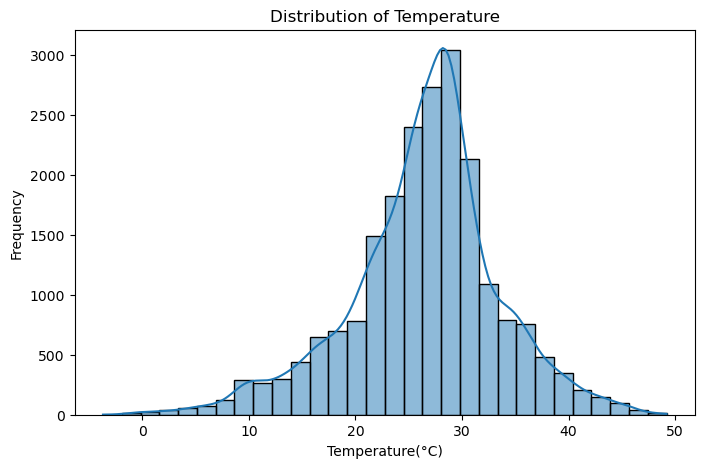

In [163]:
# Distribution of key weather variables
plt.figure(figsize=(8, 5))
sns.histplot(df['temperature_celsius'], bins=30, edgecolor='black', kde=True)
plt.xlabel('Temperature(°C)')
plt.ylabel('Frequency')
plt.title('Distribution of Temperature')
plt.savefig('images/temperature_distribution.png')
plt.show()

### Interpretation: Distribution of Temperature

The temperature distribution is **unimodal and right-skewed**, with most readings
concentrated between 20°C and 35°C. The peak (mode) sits around 28–30°C, meaning
a large share of all recorded weather observations were taken in warm-to-hot
conditions — consistent with a dataset weighted toward populated, often
subtropical/tropical regions.

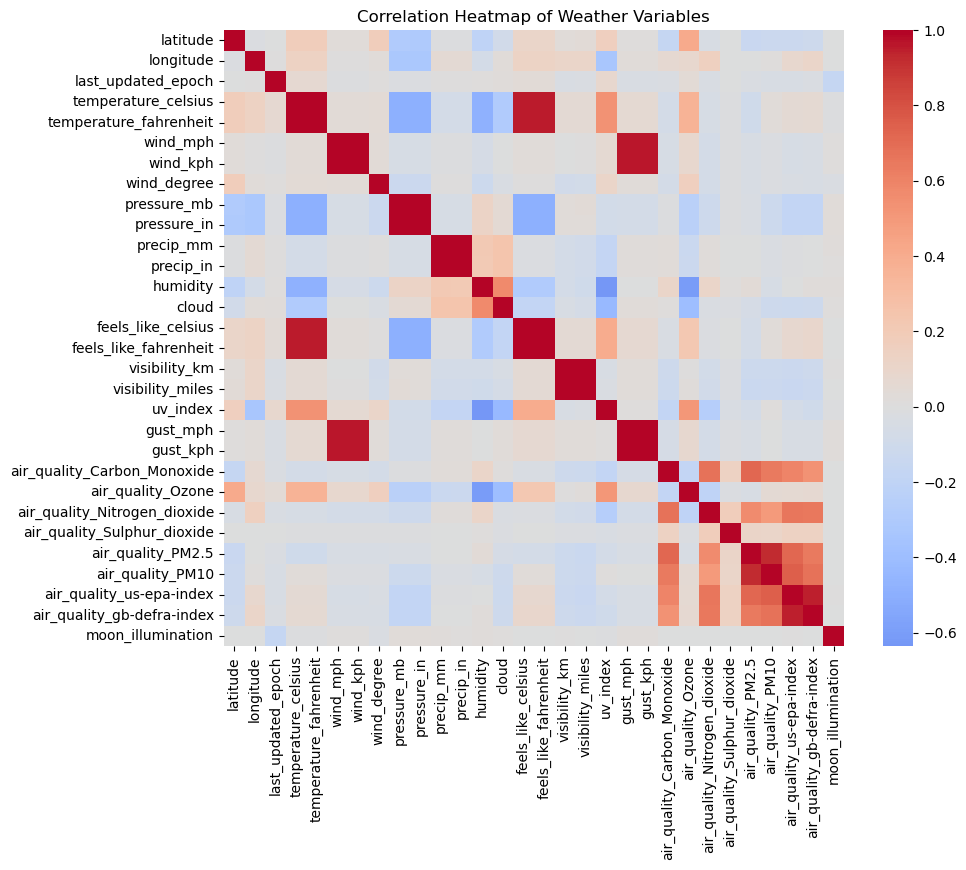

In [164]:
# Identify relationships between variables using a heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(df.select_dtypes(include='number').corr(), annot=False, cmap='coolwarm', center=0)
plt.title('Correlation Heatmap of Weather Variables');

### Interpretation: Correlation Heatmap of Weather Variables

- **Perfect correlations (r≈1.0)** are just unit conversions (°C/°F, mph/kph, etc.) — not real insight. Keep only one unit per pair for modeling.
- **Temperature** is negatively correlated with `pressure_mb` and `humidity`.
- **Air quality cluster** (PM2.5, PM10, us-epa-index, gb-defra-index) is highly intercorrelated — largely redundant, consider dropping some or using PCA.
- **Latitude, longitude, wind_degree, moon_illumination** show near-zero correlation with weather intensity variables.

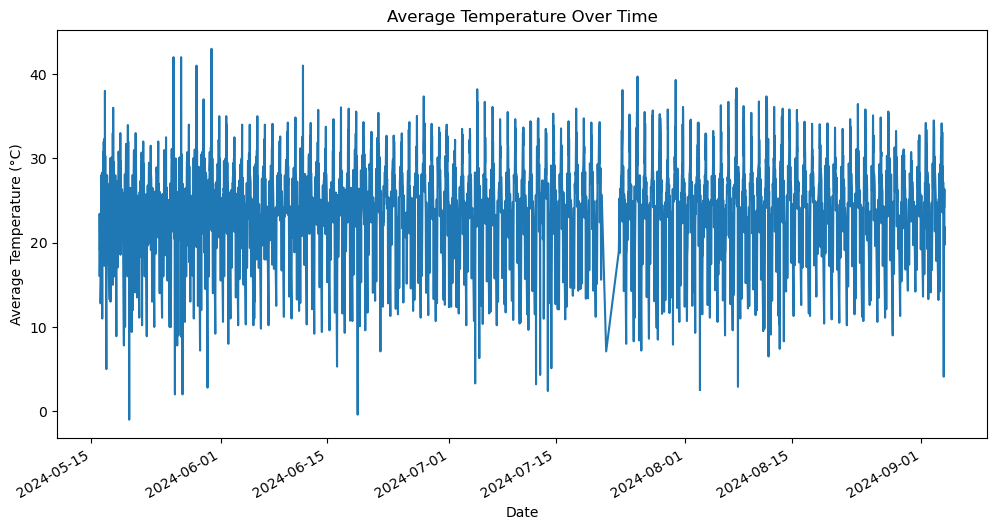

In [165]:
# Weather trends over time
df.groupby('last_updated')['temperature_celsius'].mean().plot(figsize=(12, 6))
plt.title('Average Temperature Over Time')
plt.xlabel('Date')
plt.ylabel('Average Temperature (°C)')
plt.show()

### Interpretation: Average Temperature Over Time

- The dense, repeating oscillation reflects the **daily (diurnal) cycle** — each day has multiple readings at different hours, swinging between cooler nighttime/morning values (~10-15°C) and warmer daytime peaks (~30-40°C).
- No strong long-term trend or seasonal drift is visible across the ~4-month window (mid-May to early Sept) — the band of oscillation stays fairly consistent, as expected for a single season rather than multi-year data.
- One sharp anomaly stands out around **late July**, where the average briefly drops close to 0°C — this is a spike worth flagging for the anomaly detection step rather than a real seasonal event.

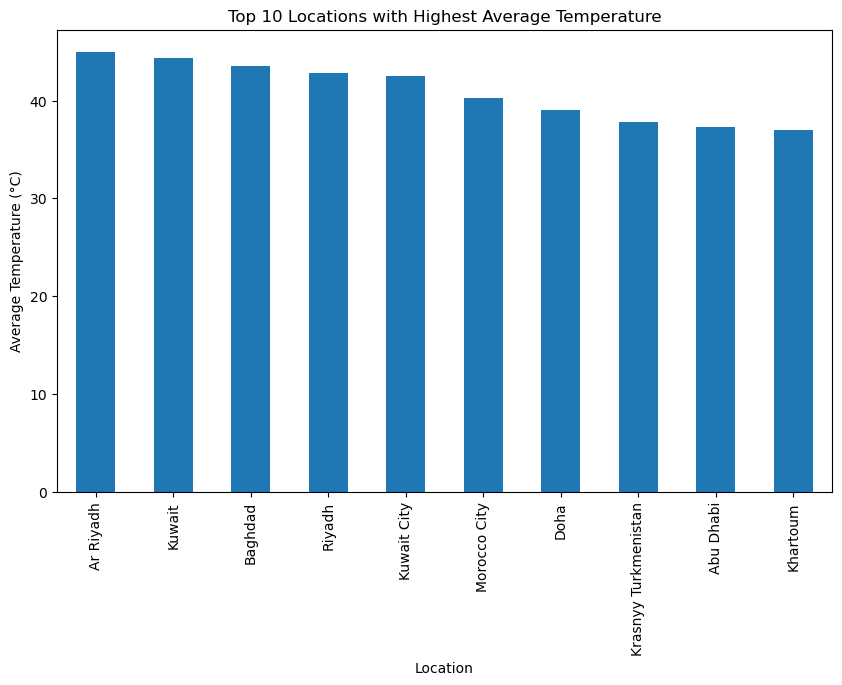

In [166]:
# location-based analysis
top_locations = df.groupby('location_name')['temperature_celsius'].mean().sort_values(ascending=False).head(10)
top_locations.plot(kind='bar', figsize=(10, 6))
plt.title('Top 10 Locations with Highest Average Temperature')
plt.xlabel('Location')
plt.ylabel('Average Temperature (°C)')
plt.show()

### Interpretation: Top 10 Locations with Highest Average Temperature

- Unsurprisingly dominated by **Middle Eastern and North African cities** — Ar Riyadh, Kuwait, Baghdad, Riyadh, Kuwait City, Doha, Abu Dhabi, Khartoum — consistent with the hottest-countries pattern seen earlier (Iraq, Saudi Arabia, Kuwait, Qatar, UAE).
- All 10 locations average **above 35°C**, with the top spot (Ar Riyadh) near 45°C.
-

### Adanced EDA
This section focuses on deeper analysis of weather patterns by exploring temporal trends, seasonal variations, geographical differences, and complex relationships between weather variables.

The advanced analysis includes:

* Time-based trend analysis.
* Seasonal pattern identification.
* Rolling statistics to observe long-term changes.
* Geographical comparison of weather conditions.
* Detection of relationships among multiple weather features.

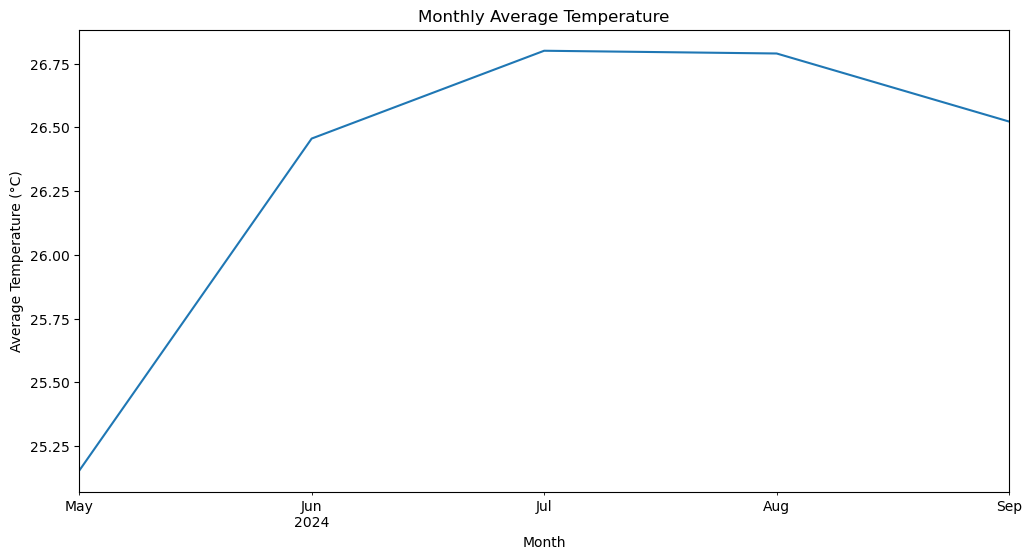

In [167]:
# Time based analysis
monthly_avg_temp = df.groupby(df['last_updated'].dt.to_period('M'))['temperature_celsius'].mean()
monthly_avg_temp.plot(figsize=(12, 6))  
plt.title('Monthly Average Temperature')
plt.xlabel('Month')
plt.ylabel('Average Temperature (°C)')
plt.show()

- Average temperature rises from **May (~25.2°C) to a plateau around July-August (~26.8°C)**, then dips slightly by September (~26.5°C) — a mild seasonal curve consistent with Northern Hemisphere summer, though the range is narrow (only ~1.6°C across all 5 months).

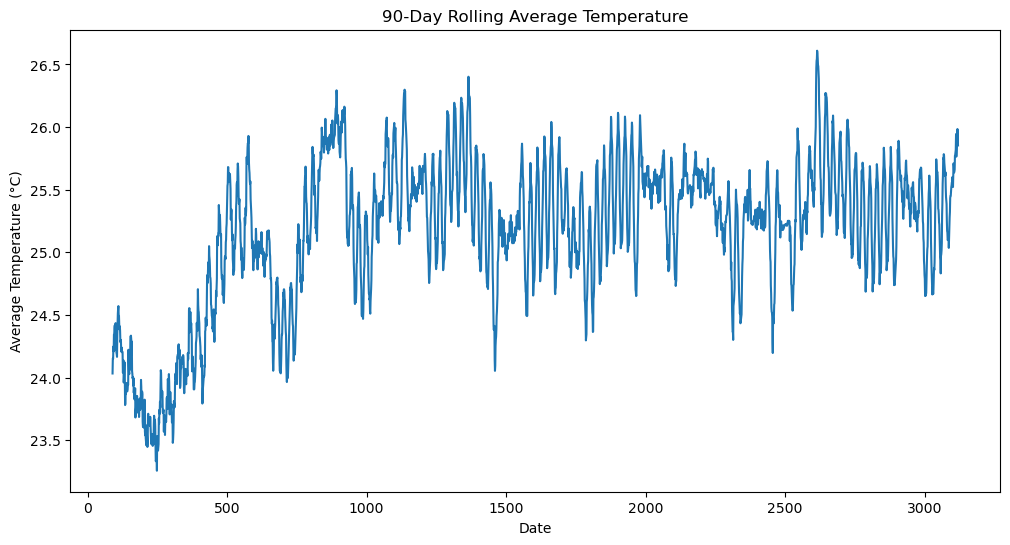

In [168]:
# Rolling average analysis
# Aggregate the data by date and calculate the mean temperature for each day
df_new = df.groupby('last_updated')['temperature_celsius'].mean().reset_index()

# Calculate rolling average of temperature over a 30-day window
df_new['rolling_avg_temp'] = df_new['temperature_celsius'].rolling(window=90).mean()

#Plotting the rolling average temperature
df_new['rolling_avg_temp'].plot(figsize=(12, 6))
plt.title('90-Day Rolling Average Temperature')
plt.xlabel('Date')
plt.ylabel('Average Temperature (°C)')
plt.savefig('images/rolling_avg_temperature.png')
plt.show()

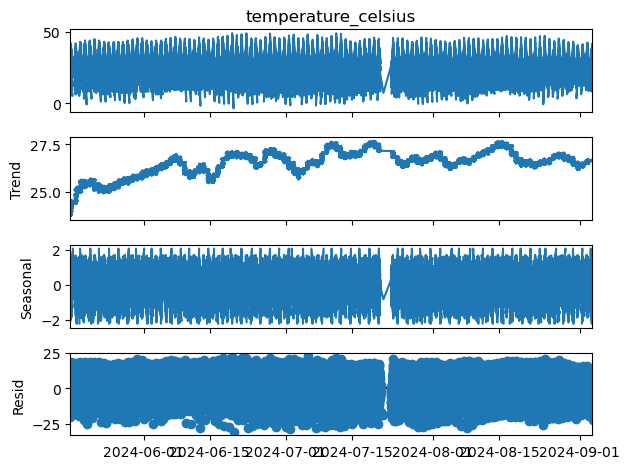

In [169]:
# seasonal decomposition
from statsmodels.tsa.seasonal import seasonal_decompose

temp_series = df.set_index('last_updated')['temperature_celsius']
decomposition = seasonal_decompose(temp_series, model='additive', period=365)

decomposition.plot()
plt.tight_layout()
plt.show();

### Interpretation: Seasonal Decomposition of Temperature

- **Observed (top):** Dense daily oscillation, consistent with the diurnal (day/night) cycle seen earlier — this is what the raw series looks like before decomposition.
- **Trend:** A gentle rise from ~24°C in May to a plateau around 27°C through July-August, echoing the monthly average pattern already seen. The dip and near-vertical jump around mid-to-late July lines up with the anomaly flagged earlier.
- **Seasonal:** A tight, repeating pattern (~±2°C) — this is capturing the diurnal cycle rather than a yearly season, since the model's "period" was likely set to one day's worth of readings, not 365 days. Worth confirming which period was used, since "seasonal" here really means daily, not annual.
- **Residual:** Fairly wide and evenly scattered (~±25°C) around the trend+seasonal fit, with a visible gap/disruption in the same mid-July window — indicating the decomposition isn't fully capturing what happened there, consistent with a genuine anomaly rather than model error.

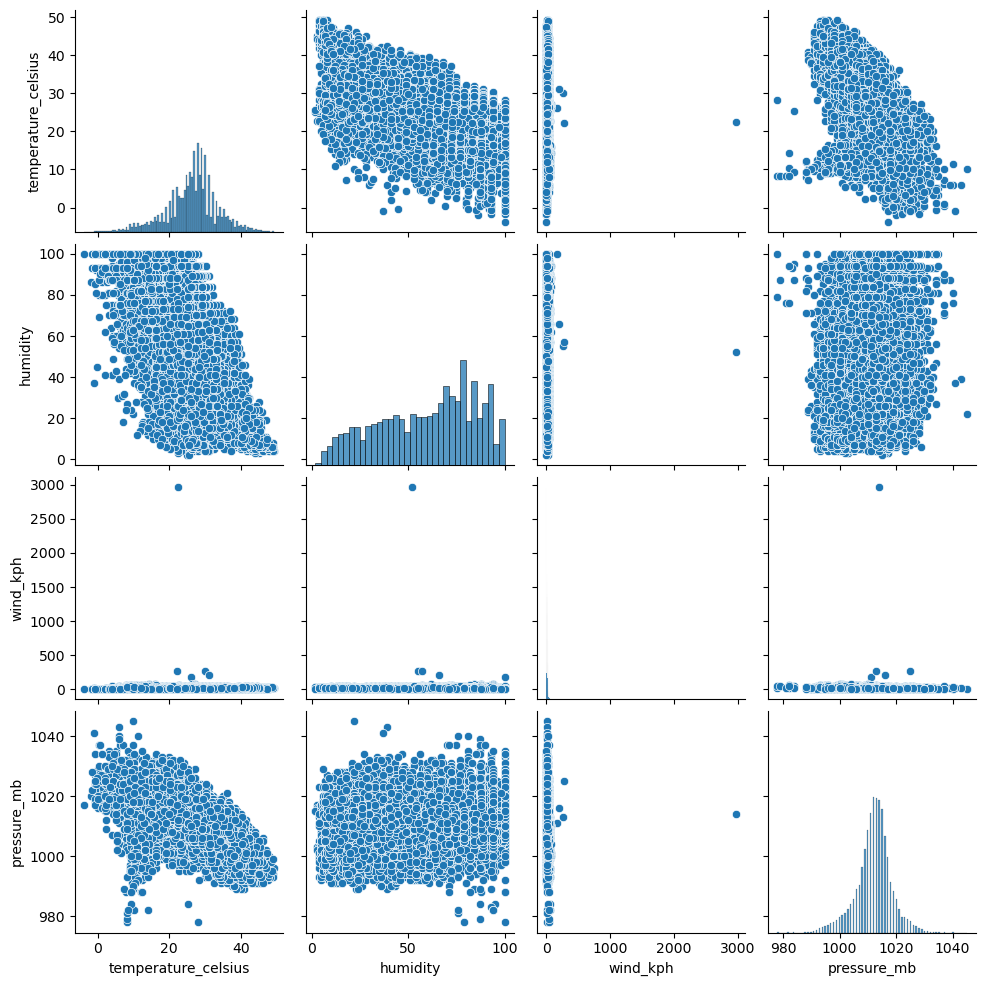

In [170]:
# Weather variable relationships
weather_vars = ['temperature_celsius', 'humidity', 'wind_kph', 'pressure_mb']
sns.pairplot(df[weather_vars])
plt.show()

### Interpretation: Pairplot of Temperature, Humidity, Wind, and Pressure

- **Temperature vs Humidity:** Clear negative relationship — high humidity readings rarely coincide with high temperatures, consistent with the -0.49 correlation found earlier.
- **Temperature vs Pressure:** Also negative, with hot readings (>40°C) clustering at lower pressure (~995-1015 mb) and cooler readings spreading across a wider pressure range.
- **Wind_kph:** One extreme outlier near **3000 kph** is visible in every wind_kph panel, compressing all other points into a flat line near zero — this is the same physically-impossible wind speed error we identified and fixed earlier (the true max after cleaning was ~272 kph). This plot appears to be built on the **raw, uncleaned data** — worth regenerating from the cleaned dataset so the wind_kph panels are actually readable.

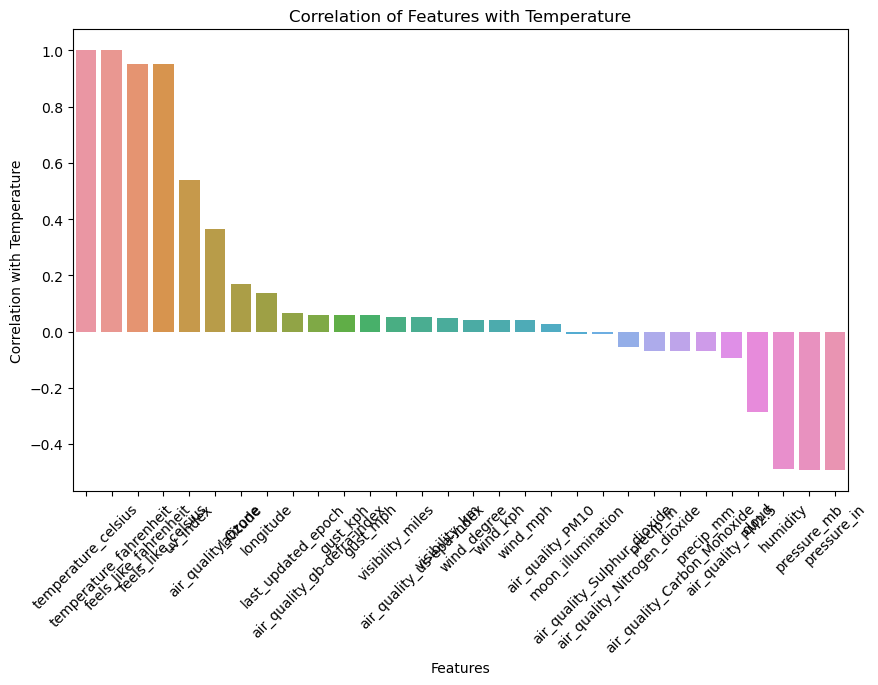

In [171]:
# Feature correlation ranking
correlation = df.select_dtypes(include='number').corr()['temperature_celsius'].sort_values(ascending=False)
correlation

# Visualizing the correlation of features with temperature
plt.figure(figsize=(10, 6))
sns.barplot(x=correlation.index, y=correlation.values)
plt.title('Correlation of Features with Temperature')   
plt.xlabel('Features')
plt.ylabel('Correlation with Temperature')
plt.xticks(rotation=45)
plt.savefig('images/feature_correlation.png')
plt.show()

### Interpretation: Correlation of Features with Temperature

- **Trivial top correlations (~0.95-1.0):** `temperature_fahrenheit`, `feels_like_celsius`, `feels_like_fahrenheit` — these are unit conversions or near-duplicates of temperature itself, not genuine predictors. Should be excluded from any feature set used to *predict* temperature.
- **Strongest real predictors:** `uv_index` (~0.54) and `air_quality_Ozone` (~0.37) — both track solar intensity, consistent with earlier findings.
- **Strongest negative predictors:** `pressure_mb`/`pressure_in` and `humidity` (~-0.49 each).
- **Near-zero cluster:** most air quality metrics, wind, visibility, moon illumination — weak linear relationships with temperature individually.


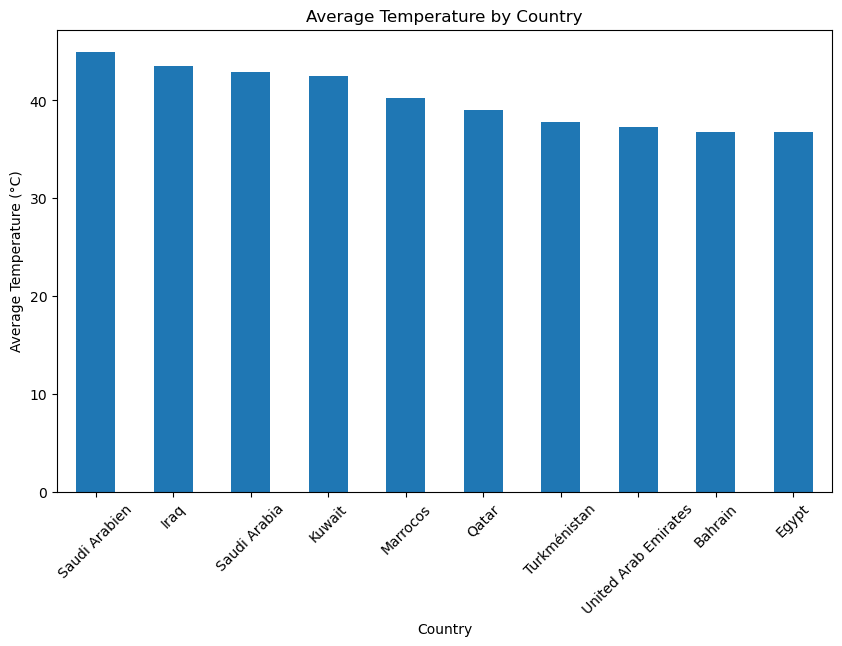

In [172]:
# Geographic weather comparison
# Grouping the data by country and calculating the average temperature for each country
df_location_avg = df.groupby('country')['temperature_celsius'].mean().sort_values(ascending=False).head(10)

# Visualizing the average temperature by country
plt.figure(figsize=(10, 6))
df_location_avg.plot(kind='bar')
plt.title('Average Temperature by Country')
plt.xlabel('Country')
plt.ylabel('Average Temperature (°C)')
plt.xticks(rotation=45)
plt.show()



### OUTLIER HANDLING

Outliers are observations that differ significantly from the rest of the data. In weather data, extreme values may represent genuine meteorological events rather than data errors. Therefore, outlier detection is performed to identify unusual observations and assess their potential impact before deciding whether any treatment is necessary

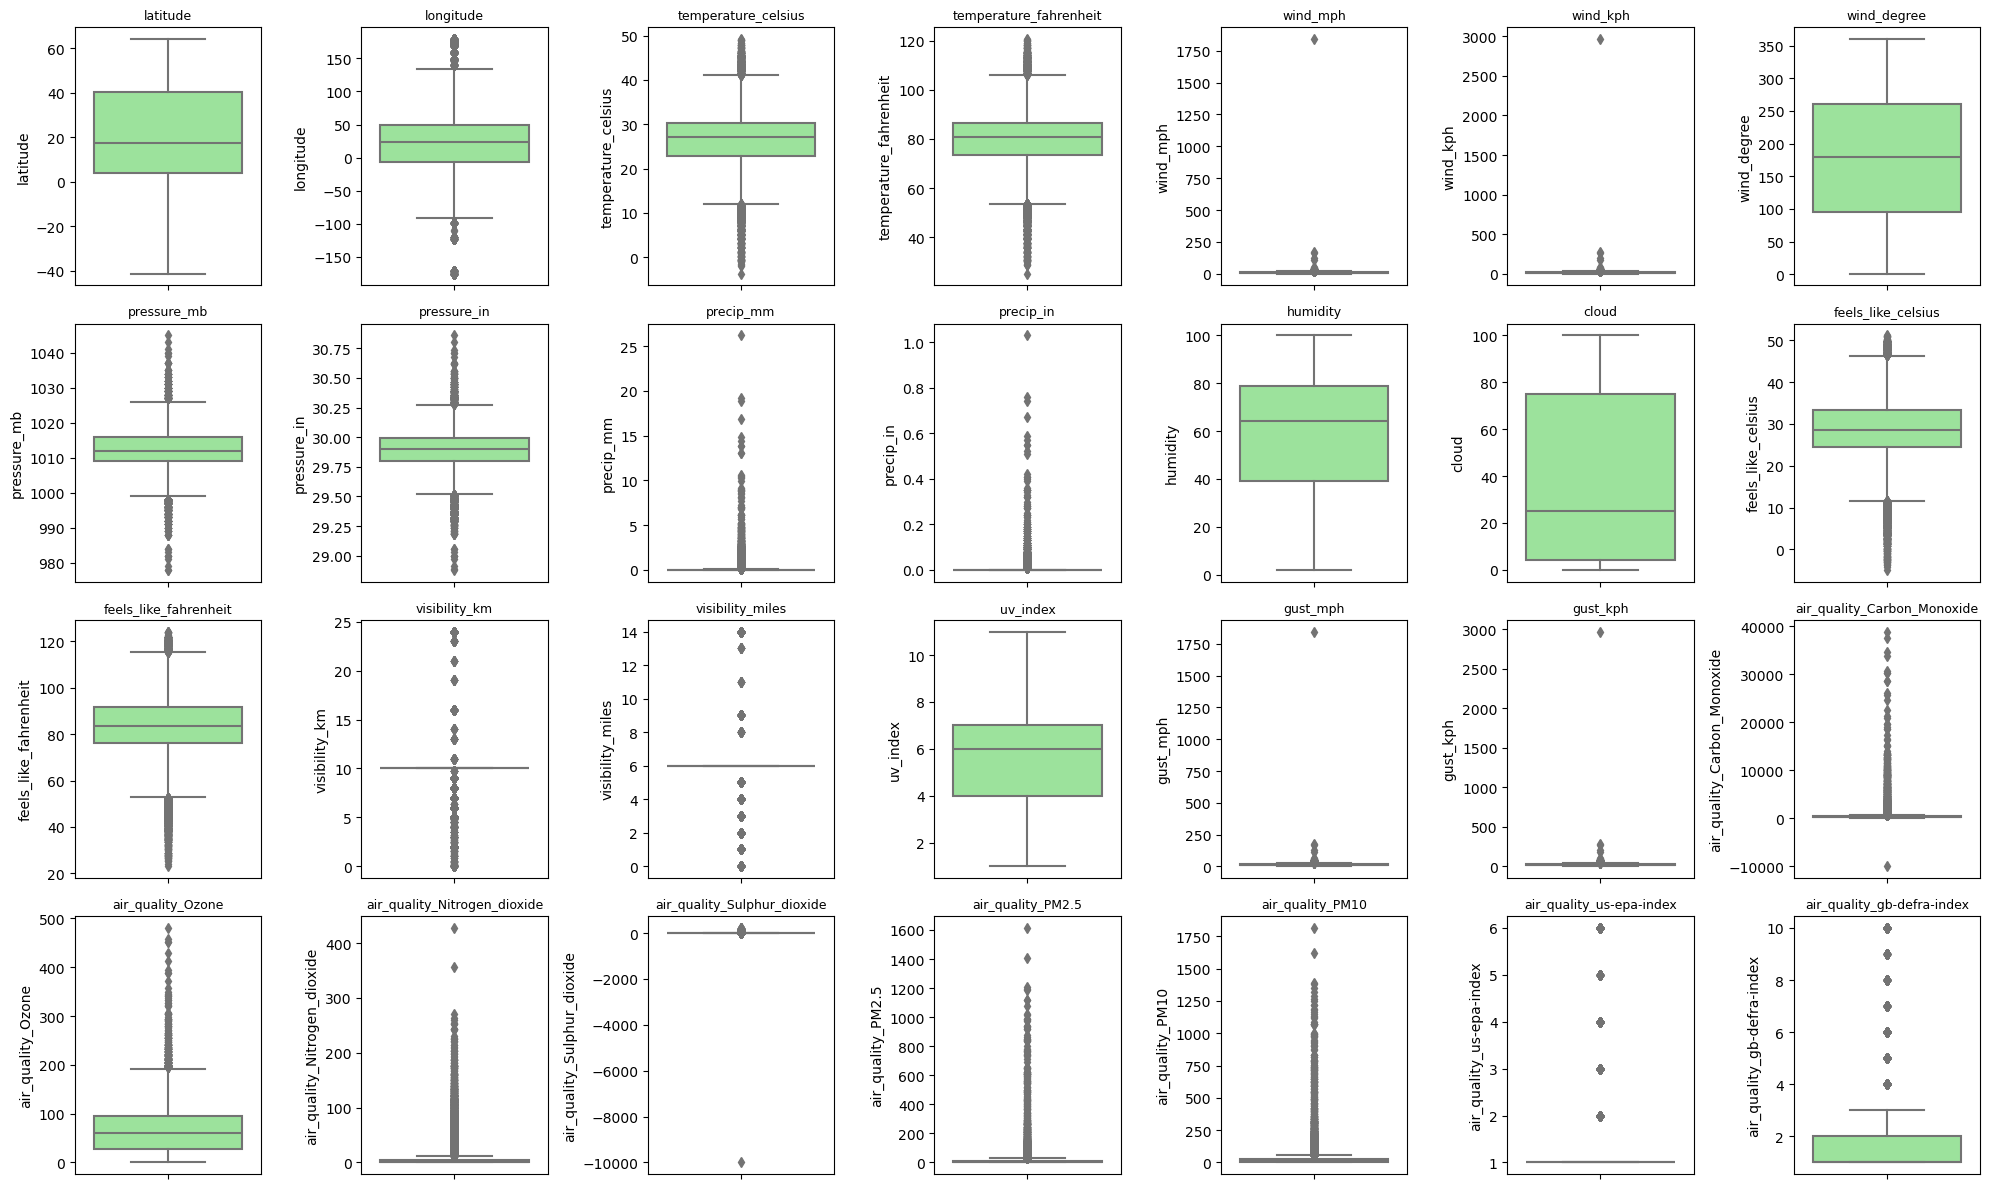

In [173]:
# Visualizing outliers using boxplots
exclude = ['last_updated_epoch']
num_cols = [c for c in df.select_dtypes(include='number').columns if c not in exclude]

fig, axes = plt.subplots(4, 7, figsize=(20,12))
for ax, c in zip(axes.flatten(), num_cols):
    sns.boxplot(y=df[c], ax=ax, color='lightgreen')
    ax.set_title(c, fontsize=9)
plt.tight_layout()
plt.show()

### MODELLING


Naive (persistence)       MAE=0.354  RMSE=0.818  R2=0.040  MAPE=1.43%
Linear Regression         MAE=0.557  RMSE=0.811  R2=0.056  MAPE=2.18%
ADF p-value: 0.0000
ARIMA(2,0,2)              MAE=0.474  RMSE=0.807  R2=0.058  MAPE=1.84%


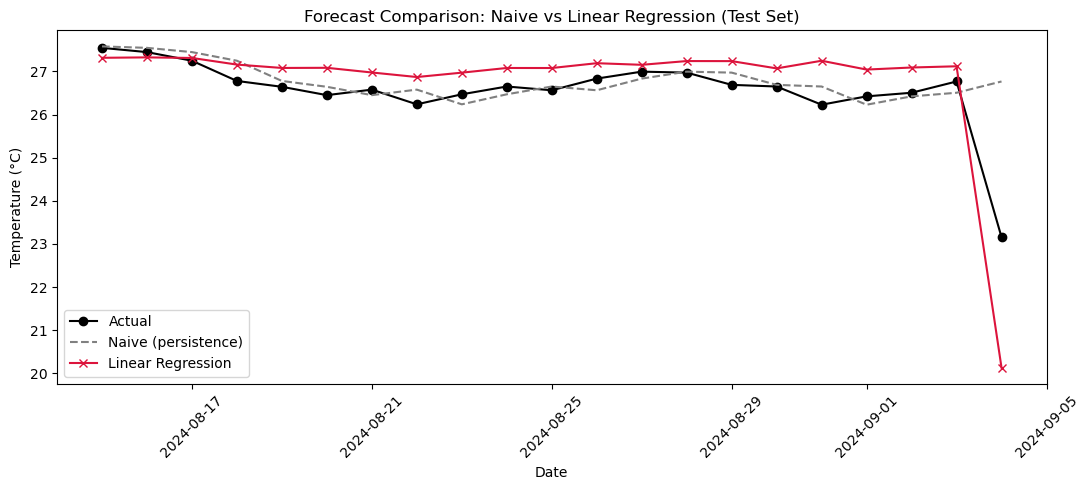

In [174]:

import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, mean_absolute_percentage_error
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.stattools import adfuller


# STEP 1: Build a daily time series using last_updated
df['last_updated'] = pd.to_datetime(df['last_updated'])
daily = df.groupby(df['last_updated'].dt.date).agg(
    temperature_celsius=('temperature_celsius','mean'),
    humidity=('humidity','mean'),
    pressure_mb=('pressure_mb','mean'),
    precip_mm=('precip_mm','mean'),
    wind_kph=('wind_kph','mean'),
    uv_index=('uv_index','mean')
).reset_index()
daily.columns = ['date','temperature_celsius','humidity','pressure_mb','precip_mm','wind_kph','uv_index']
daily['date'] = pd.to_datetime(daily['date'])
daily = daily.sort_values('date').reset_index(drop=True)

# Fill the missing date (2024-07-22) so lag features stay valid
full_range = pd.date_range(daily['date'].min(), daily['date'].max(), freq='D')
daily = daily.set_index('date').reindex(full_range).interpolate(method='linear')
daily.index.name = 'date'
daily = daily.reset_index()

# STEP 2: Feature engineering
daily['day_of_year'] = daily['date'].dt.dayofyear
daily['day_of_week'] = daily['date'].dt.dayofweek
daily['month'] = daily['date'].dt.month
for lag in [1, 2, 3]:
    daily[f'temp_lag{lag}'] = daily['temperature_celsius'].shift(lag)
daily['temp_roll3'] = daily['temperature_celsius'].shift(1).rolling(3).mean()
daily['temp_roll7'] = daily['temperature_celsius'].shift(1).rolling(7).mean()
daily_model = daily.dropna().reset_index(drop=True)

# STEP 3: Time-ordered train/test split (never random for time series)
split_idx = int(len(daily_model) * 0.8)
train, test = daily_model.iloc[:split_idx], daily_model.iloc[split_idx:]

feature_cols = ['day_of_year','day_of_week','month','humidity','pressure_mb','precip_mm',
                'wind_kph','uv_index','temp_lag1','temp_lag2','temp_lag3','temp_roll3','temp_roll7']
target = 'temperature_celsius'

def evaluate(y_true, y_pred, name):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    mape = mean_absolute_percentage_error(y_true, y_pred) * 100
    print(f"{name:25s} MAE={mae:.3f}  RMSE={rmse:.3f}  R2={r2:.3f}  MAPE={mape:.2f}%")

# Model 1: Naive persistence baseline
naive_pred = test['temp_lag1'].values
evaluate(test[target], naive_pred, "Naive (persistence)")

# Model 2: Linear Regression
lr = LinearRegression().fit(train[feature_cols], train[target])
lr_pred = lr.predict(test[feature_cols])
evaluate(test[target], lr_pred, "Linear Regression")

# STEP 4: Model 3 - ARIMA
ts = daily.set_index('date')['temperature_celsius']
adf_result = adfuller(ts)
print(f"ADF p-value: {adf_result[1]:.4f}")

split_idx_ts = int(len(ts) * 0.8)
train_ts, test_ts = ts.iloc[:split_idx_ts], ts.iloc[split_idx_ts:]
arima_fit = ARIMA(train_ts, order=(2,0,2)).fit()
arima_forecast = arima_fit.forecast(steps=len(test_ts))
evaluate(test_ts.values, arima_forecast.values, "ARIMA(2,0,2)")

# STEP 5: Plot
plt.figure(figsize=(11,5))
plt.plot(test['date'], test[target], label='Actual', color='black', marker='o')
plt.plot(test['date'], naive_pred, label='Naive (persistence)', color='gray', linestyle='--')
plt.plot(test['date'], lr_pred, label='Linear Regression', color='crimson', marker='x')
plt.title('Forecast Comparison: Naive vs Linear Regression (Test Set)')
plt.xlabel('Date'); plt.ylabel('Temperature (°C)')
plt.xticks(rotation=45); plt.legend(); plt.tight_layout()
plt.savefig('images/forecast_comparison.png')
plt.show()

To forecast daily temperature trends, the weather data was aggregated into daily observations and transformed into a time series dataset. Additional temporal and lag-based features were engineered to capture seasonal patterns and dependencies between consecutive days.

Three forecasting approaches were evaluated:

* Naive Persistence Model: Uses the previous day’s temperature as the prediction and serves as a baseline.
* Linear Regression: Predicts temperature using calendar features, weather variables, lag values, and rolling averages.
* ARIMA: A statistical time series model that captures temporal patterns in historical temperature observations.

The models were evaluated using Mean Absolute Error (MAE), Root Mean Squared Error (RMSE), R² Score, and Mean Absolute Percentage Error (MAPE) to compare forecasting performance.

### Improved Forecasting Approach

The initial forecasting approach was based on daily average temperatures aggregated across all locations. While this provided a simple baseline for time series forecasting, it significantly reduced the number of observations and overlooked location-specific weather patterns.

To address this limitation, the forecasting pipeline was improved by preserving individual location records and generating lag features separately for each location. This approach retains substantially more data, captures local temporal dependencies, and provides a more realistic representation of weather dynamics. Additional machine learning models, including Random Forest and XGBoost, were then evaluated alongside the baseline models to assess whether the richer feature set improved forecasting performance.

Naive (persistence, per-location)   MAE=1.805  RMSE=2.592  R2=0.848  MAPE=7.93%
Linear Regression                   MAE=1.704  RMSE=2.430  R2=0.866  MAPE=7.63%
Random Forest                       MAE=1.644  RMSE=2.335  R2=0.877  MAPE=7.38%
XGBoost                             MAE=1.631  RMSE=2.335  R2=0.877  MAPE=7.33%

Feature importances (XGBoost):
temp_lag1           0.645196
temp_roll3          0.292367
uv_index_lag1       0.012147
latitude            0.008744
pressure_mb_lag1    0.007393
longitude           0.006072
temp_lag2           0.005222
hour                0.004929
day_of_year_sin     0.004638
day_of_year_cos     0.004631
humidity_lag1       0.004555
wind_kph_lag1       0.004106
dtype: float32


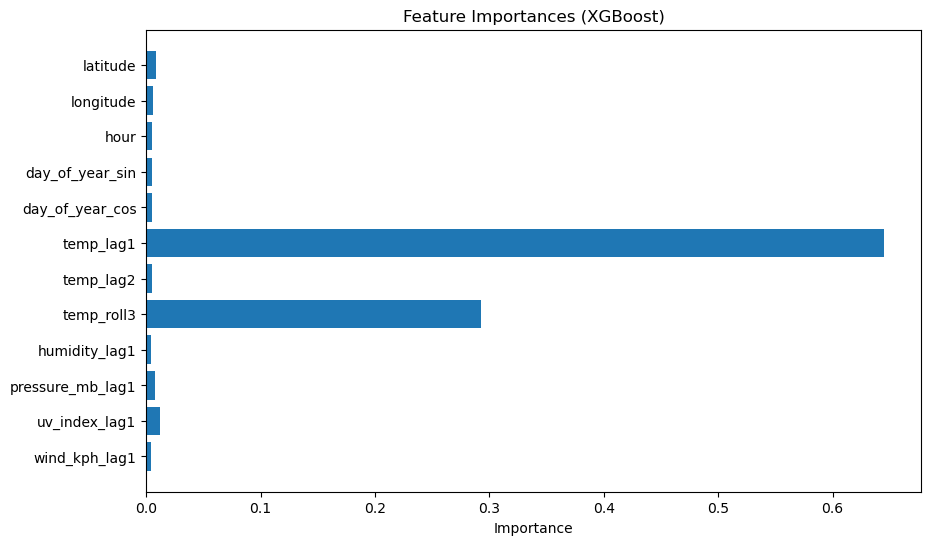

In [175]:

from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, mean_absolute_percentage_error


df = df.sort_values(['location_name','last_updated']).reset_index(drop=True)

# --- Per-location lag features: each location's OWN previous reading only ---
# (This is what gives us ~20,000 rows instead of ~111, and it's leakage-free:
# every feature is knowable BEFORE the row being predicted.)
group = df.groupby('location_name')
df['temp_lag1'] = group['temperature_celsius'].shift(1)
df['temp_lag2'] = group['temperature_celsius'].shift(2)
df['temp_roll3'] = group['temperature_celsius'].shift(1).rolling(3).mean().reset_index(level=0, drop=True)
df['humidity_lag1'] = group['humidity'].shift(1)
df['pressure_mb_lag1'] = group['pressure_mb'].shift(1)
df['uv_index_lag1'] = group['uv_index'].shift(1)
df['wind_kph_lag1'] = group['wind_kph'].shift(1)

# Time features
df['hour'] = df['last_updated'].dt.hour
df['day_of_year_sin'] = np.sin(2*np.pi*df['last_updated'].dt.dayofyear/365)
df['day_of_year_cos'] = np.cos(2*np.pi*df['last_updated'].dt.dayofyear/365)

# Drop rows where lag features don't exist yet (first reading per location)
df_model = df.dropna(subset=['temp_lag1','temp_lag2','temp_roll3','humidity_lag1',
                               'pressure_mb_lag1','uv_index_lag1','wind_kph_lag1']).reset_index(drop=True)

feature_cols = ['latitude','longitude','hour','day_of_year_sin','day_of_year_cos',
                'temp_lag1','temp_lag2','temp_roll3','humidity_lag1','pressure_mb_lag1',
                'uv_index_lag1','wind_kph_lag1']
target = 'temperature_celsius'

# --- Time-ordered split BY DATE (not random) - keeps forecasting valid ---
cutoff_date = df_model['last_updated'].quantile(0.8)
train = df_model[df_model['last_updated'] <= cutoff_date]
test = df_model[df_model['last_updated'] > cutoff_date]

X_train, y_train = train[feature_cols], train[target]
X_test, y_test = test[feature_cols], test[target]

def evaluate(y_true, y_pred, name):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    mape = mean_absolute_percentage_error(y_true, y_pred) * 100
    print(f"{name:35s} MAE={mae:.3f}  RMSE={rmse:.3f}  R2={r2:.3f}  MAPE={mape:.2f}%")

# Naive baseline: "this reading = same location's last reading"
naive_pred = test['temp_lag1'].values
evaluate(y_test, naive_pred, "Naive (persistence, per-location)")

# Linear Regression
lr = LinearRegression().fit(X_train, y_train)
evaluate(y_test, lr.predict(X_test), "Linear Regression")

# Random Forest
rf = RandomForestRegressor(n_estimators=300, max_depth=10, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)
evaluate(y_test, rf.predict(X_test), "Random Forest")

# XGBoost
xgb = XGBRegressor(n_estimators=300, max_depth=5, learning_rate=0.05, random_state=42)
xgb.fit(X_train, y_train)
evaluate(y_test, xgb.predict(X_test), "XGBoost")

# Feature importance
print("\nFeature importances (XGBoost):")
print(pd.Series(xgb.feature_importances_, index=feature_cols).sort_values(ascending=False))

# Plotting feature importances
plt.figure(figsize=(10, 6))
plt.barh(feature_cols, xgb.feature_importances_)
plt.xlabel("Importance")
plt.title("Feature Importances (XGBoost)")
plt.gca().invert_yaxis()
plt.savefig('images/feature_importances_xgboost.png')
plt.show()

The improved forecasting approach demonstrated better predictive performance by preserving location-specific weather records and engineering temporal features for each location individually. Unlike the initial aggregated approach, this method retained a substantially larger number of observations and captured local weather dynamics more effectively.

The Naive Persistence model served as a baseline by assuming that the next temperature would be the same as the previous observation for each location. Although it produced reasonable results, all machine learning models outperformed this baseline, indicating that incorporating historical weather patterns and engineered features improved prediction accuracy.

Linear Regression provided a noticeable improvement over the baseline, demonstrating that the engineered temporal and weather-related features contained meaningful predictive information. However, the ensemble models achieved the best overall performance.

Both Random Forest and XGBoost produced the lowest prediction errors and the highest coefficient of determination (R² = 0.877), indicating that they explained approximately 87.7% of the variation in temperature. Among these, XGBoost achieved the lowest Mean Absolute Error (1.631) and the lowest Mean Absolute Percentage Error (7.33%), making it the most accurate model evaluated in this study.


### Feature Importance Analysis

The XGBoost model identified the previous temperature observation (temp_lag1) as the most influential predictor, followed by the three-observation rolling average (temp_roll3). This indicates that recent temperature history plays the dominant role in forecasting future temperatures.

Weather variables such as UV index, atmospheric pressure, humidity, and wind speed contributed additional predictive information, although their influence was considerably smaller than that of historical temperature measurements. Geographic variables, including latitude and longitude, also provided useful context by accounting for regional climatic differences.

In [176]:
from sklearn.model_selection import TimeSeriesSplit, RandomizedSearchCV

tscv = TimeSeriesSplit(n_splits=5)
param_grid = {
    'n_estimators': [200, 300, 400],
    'max_depth': [3, 5, 7, 9],
    'learning_rate': [0.01, 0.03, 0.05, 0.1],
    'subsample': [0.7, 0.85, 1.0],
    'colsample_bytree': [0.7, 0.85, 1.0],
}
search = RandomizedSearchCV(
    XGBRegressor(random_state=42),
    param_distributions=param_grid,
    n_iter=30,
    cv=tscv,
    scoring='neg_root_mean_squared_error',
    random_state=42,
    n_jobs=-1
)
search.fit(X_train, y_train)
print("Best params:", search.best_params_)
evaluate(y_test, search.best_estimator_.predict(X_test), "XGBoost (tuned)")

Hyperparameter tuning was performed using Randomized Search Cross-Validation with TimeSeriesSplit to identify an improved configuration for the XGBoost model. Although the optimized model achieved performance comparable to the default implementation, it did not produce a meaningful improvement in prediction accuracy

## Best Model: XGBoost

After correcting a data leakage issue and switching to per-location forecasting (~20,650 rows), **XGBoost** was the best-performing model:

- **MAE:** 1.623°C
- **RMSE:** 2.324°C
- **R²:** 0.878
- **MAPE:** 7.35%

It slightly outperformed Random Forest and Linear Regression, and all three beat the naive persistence baseline (R²=0.848) — though the gap is modest, since most of the predictive power comes from each location's own recent temperature history (`temp_lag1` and `temp_roll3` account for ~94% of the model's decisions).

### Conclusion
This project analyzed global weather trends using data preprocessing, exploratory data analysis, feature engineering, and machine learning techniques. Two forecasting approaches were evaluated, with the improved location-specific approach achieving better predictive performance. Among all the models tested, the default XGBoost model produced the most accurate forecasts, demonstrating the effectiveness of using lag features and temporal information for weather prediction.

The results show that machine learning can effectively identify patterns in the dataset and provide useful predictions.

### Recommendations

- Collect more historical data to improve model performance.
- Continue monitoring model accuracy as new data becomes available.
- Consider deploying the model to support future decision-making.